In [12]:
#After executing the below command restart the kernel and run all cells.
!pip3 install scikit-learn --upgrade --user

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   --------------- ------------------------ 3.1/8.0 MB 17.8 MB/s eta 0:00:01
   ---------------------- ----------------- 4.5/8.0 MB 14.4 MB/s eta 0:00:01
   -------------------------------------- - 7.6/8.0 MB 13.1 MB/s eta 0:00:01
   ---------------------------------------- 8.0/8.0 MB 11.5 MB/s  0:00:00


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler,PolynomialFeatures
from sklearn.linear_model import LinearRegression
%matplotlib inline

In [14]:
file_name='https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/FinalModule_Coursera/data/kc_house_data_NaN.csv'
df=pd.read_csv(file_name)

In [6]:
df.head()

,Unnamed: 0,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,0,7129300520,20141013T000000,221900.0,3.0,1.00,1180,5650,1.0,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,1,6414100192,20141209T000000,538000.0,3.0,2.25,2570,7242,2.0,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,2,5631500400,20150225T000000,180000.0,2.0,1.00,770,10000,1.0,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,3,2487200875,20141209T000000,604000.0,4.0,3.00,1960,5000,1.0,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,4,1954400510,20150218T000000,510000.0,3.0,2.00,1680,8080,1.0,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [7]:
# Display data types of each column

df.dtypes

Unnamed: 0         int64
id                 int64
date              object
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
dtype: object

In [8]:
# Drop unnecessary columns if they exist

df.drop(["id", "Unnamed: 0"], axis=1, inplace=True, errors="ignore")

# Display statistical summary of the dataset

df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
count,2.161300e+04,21600.000000,21603.000000,21613.000000,2.161300e+04,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000,21613.000000
mean,5.400881e+05,3.372870,2.115736,2079.899736,1.510697e+04,1.494309,0.007542,0.234303,3.409430,7.656873,1788.390691,291.509045,1971.005136,84.402258,98077.939805,47.560053,-122.213896,1986.552492,12768.455652
std,3.671272e+05,0.926657,0.768996,918.440897,4.142051e+04,0.539989,0.086517,0.766318,0.650743,1.175459,828.090978,442.575043,29.373411,401.679240,53.505026,0.138564,0.140828,685.391304,27304.179631
min,7.500000e+04,1.000000,0.500000,290.000000,5.200000e+02,1.000000,0.000000,0.000000,1.000000,1.000000,290.000000,0.000000,1900.000000,0.000000,98001.000000,47.155900,-122.519000,399.000000,651.000000
25%,3.219500e+05,3.000000,1.750000,1427.000000,5.040000e+03,1.000000,0.000000,0.000000,3.000000,7.000000,1190.000000,0.000000,1951.000000,0.000000,98033.000000,47.471000,-122.328000,1490.000000,5100.000000
50%,4.500000e+05,3.000000,2.250000,1910.000000,7.618000e+03,1.500000,0.000000,0.000000,3.000000,7.000000,1560.000000,0.000000,1975.000000,0.000000,98065.000000,47.571800,-122.230000,1840.000000,7620.000000
75%,6.450000e+05,4.000000,2.500000,2550.000000,1.068800e+04,2.000000,0.000000,0.000000,4.000000,8.000000,2210.000000,560.000000,1997.000000,0.000000,98118.000000,47.678000,-122.125000,2360.000000,10083.000000
max,7.700000e+06,33.000000,8.000000,13540.000000,1.651359e+06,3.500000,1.000000,4.000000,5.000000,13.000000,9410.000000,4820.000000,2015.000000,2015.000000,98199.000000,47.777600,-121.315000,6210.000000,871200.000000


In [9]:
# Check duplicate rows

df.duplicated().sum()

np.int64(0)

In [10]:
# Q1.3 Count the number of houses for each floor value

df['floors'].value_counts().to_frame()

,count
floors,
1.0,10680
2.0,8241
1.5,1910
3.0,613
2.5,161
3.5,8


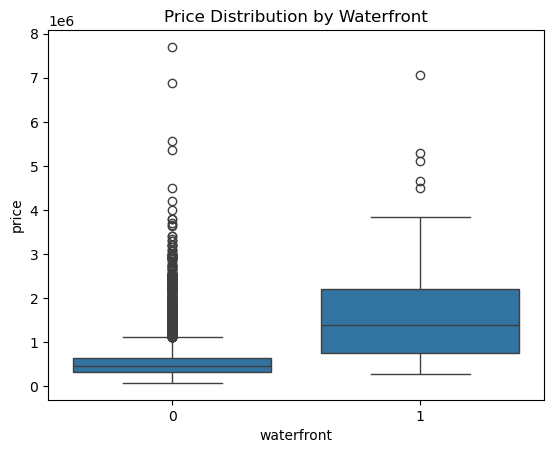

In [15]:
# Q1.4 Compare house price distribution for waterfront vs non-waterfront houses

sns.boxplot(x='waterfront', y='price', data=df)

plt.title("Price Distribution by Waterfront")
plt.show()

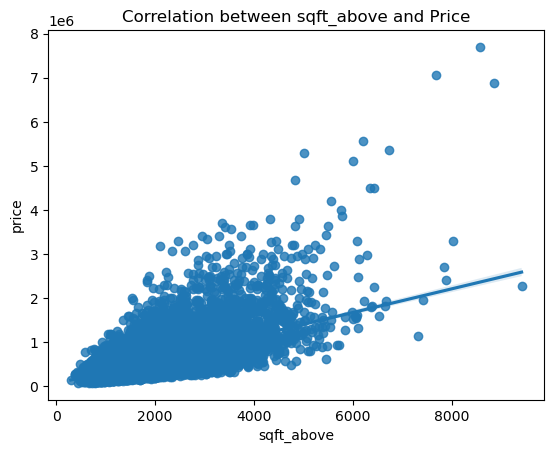

In [17]:

sns.regplot(x='sqft_above', y='price', data=df)
plt.title("Correlation between sqft_above and Price")
plt.show()

In [15]:
# Q1.6 Linear Regression using sqft_living to predict price

# Define predictor (X) and target variable (y)
X = df[['sqft_living']]
y = df['price']

# Create the linear regression model
lm = LinearRegression()

# Fit the model
lm.fit(X, y)

# Calculate R^2 score
R2 = lm.score(X, y)

print("R^2:", R2)

R^2: 0.4928532179037931


In [17]:

# Create a pipeline with a single step: Linear Regression
pipeline = Pipeline([
    ('model', LinearRegression())
])

# Fit the pipeline
pipeline.fit(X, y)

# Calculate R²
r2_pipeline = pipeline.score(X, y)
print("R² using pipeline:", r2_pipeline)

R² using pipeline: 0.6576951666037503


In [18]:
# Step 2: Split the dataset into train and test sets
# 80% training data, 20% testing data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [19]:
# Step 3: Initialize Ridge Regression model
# alpha=0.1 controls how strong the regularization is
ridge = Ridge(alpha=0.1)

In [20]:
# Step 4: Train the Ridge Regression model using the training data
ridge.fit(X_train, y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [21]:
# Step 5: Evaluate model performance on unseen test data
r2_ridge = ridge.score(X_test, y_test)
print("R² for Ridge regression on test data:", r2_ridge)

R² for Ridge regression on test data: 0.6613982983090934


In [25]:
# Step 3: Create Ridge regression model with alpha=0.1
ridge_poly = Ridge(alpha=0.1)
# Step 4: Train Ridge model on polynomial features
ridge_poly.fit(X_train_poly, y_train)

,alpha,0.1
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [26]:
# Step 5: Evaluate performance on test data
r2_poly_ridge = ridge_poly.score(X_test_poly, y_test)
print("R² for 2nd-order polynomial Ridge regression:", r2_poly_ridge)

R² for 2nd-order polynomial Ridge regression: 0.7000720055475955
